# Relatório Preliminar – Diárias e Passagens (Opção A: Regressão)

**Renê Estevam Deckers** - Introdução a Machine Learning

Este relatório segue a estrutura do **template da disciplina** (relatório preliminar – Fase 1), adaptada ao contexto do **SCDP** (Sistema de Custos de Diárias e Passagens) e à **Opção A** de modelagem: regressão para previsão do valor da despesa.

---

## 1. Descrição da Base de Dados

* ### **Fonte dos dados:**  
  Base obtida em **dados abertos do governo federal**, via Portal da Transparência e conjunto *Viagens a Serviço do Governo Federal (SCDP)* em [dados.gov.br](https://dados.gov.br/dados/conjuntos-dados/viagens-a-servico-do-governo-federal-scdp). O arquivo utilizado é o CSV **DiariasEPassagens_ultimos_2_anos.csv**, contendo registros de diárias e passagens dos **últimos 2 anos** da administração pública federal (Poder Executivo).

* ### **Contextualização:**  
  Cada **linha** representa um **trecho de viagem** ou um lançamento de diária: está vinculada a um servidor, a um órgão (e unidade gestora), às datas de início e término da viagem, ao **motivo** oficial, aos valores em reais (valor total, valor de diárias, valor de passagem) e ao **meio de transporte** quando há deslocamento. Pode haver **múltiplas linhas por viagem** (vários trechos ou lançamentos separados de diária e passagem). A base permite analisar padrões de gastos por órgão, motivo, meio de transporte e período, com relevância para **transparência**, **controle de custos** e **sustentabilidade** (redução de viagens e preferência por meios menos poluentes).

* ### **Objetivo da utilização:**  
  Analisar padrões de gastos e preparar a **modelagem de regressão** para **prever o valor da despesa** (valor total do registro, ou valor de diárias/passagens), com vistas a orçamento, metas de redução de custos e apoio à auditoria.

* ### **Problema de pesquisa:**  
  *É possível prever o valor total da despesa (ou o valor de diárias/passagens) a partir de características da viagem e do órgão?*  
  Tipo de aprendizado: **supervisionado — Regressão**.

* ### **O que vai prever?**  
  **Variável alvo (target):** **Valor total** (em R$), representando o custo total do registro (diárias + passagens). Alternativas para análises futuras: Valor diárias ou Valor passagem em subconjuntos específicos da base.

---

## 2. Dicionário de Dados

O dicionário de dados deve ser entregue **em arquivo separado (Excel)**.

O dicionário de dados foi gerado conforme o template (arquivo separado).  
- **Arquivo Excel (entrega):** `dicionario_dados.xlsx` — contém as **23 variáveis** da base, com colunas: ordem (#), Nome do campo, Tipo sugerido, Unidade ou valores, Descrição.  
- **Arquivo CSV (mesmo conteúdo):** `dicionario_dados.csv` — mesmo dicionário em formato texto (separador `;`) para versionamento e abertura em planilhas.  
- **Conteúdo:** para cada variável: tipo (numérico/categórico/data), unidade de medida e significado.

A base possui **23 variáveis**. Abaixo, resumo das mais relevantes para a **Opção A (regressão)**:

| Variável | Tipo | Unidade / valores | Observação |
|----------|------|-------------------|------------|
| Valor total | Numérico | R$ | **Variável alvo** do modelo de regressão. |
| Valor diárias | Numérico | R$ | Candidata a target ou feature; formato original pode usar vírgula decimal. |
| Valor passagem | Numérico | R$ | Candidata a target ou feature; zero quando não há passagem. |
| Número diárias | Numérico | Quantidade | Forte candidata a preditora. |
| Data início/término viagem | Data/datetime | AAAA-MM-DD (e hora) | Permitem derivar duração, mês e ano. |
| Motivo | Categórico | Texto (ex.: Nacional - A Serviço, Audiência) | Preditora após encoding. |
| Meio de transporte | Categórico | Ex.: Aéreo, Rodoviário, Veículo Oficial | Preditora; relevante para sustentabilidade. |
| Código/Nome órgão (superior, órgão, unidade gestora) | Numérico / Categórico | Códigos e nomes | Identificação do órgão; uso como feature pode exigir agrupamento. |
| Município/UF origem e destino | Categórico | Texto / sigla UF | Muitos nulos quando o registro é apenas diária (sem trecho de passagem). |
| Cargo, Categoria passagem | Categórico | Texto | Cargo com muitos nulos; Categoria passagem nula quando não há passagem. |

A descrição **completa** das 23 variáveis (tipo, unidade e significado) está no documento `pre_projeto_diarias_passagens.md` (Seção 4) e deve ser reproduzida no arquivo Excel anexo.

---

## 3. Análises Descritivas Iniciais

### 3.1 Medidas de Posição e Dispersão

Objetivo: obter **tabelas e resumos estatísticos** para as variáveis numéricas principais, incluindo:

- **Posição:** média, mediana, mínimo, máximo, quartis (Q1, Q3).  
- **Dispersão:** desvio-padrão e **coeficiente de variação (CV%)** — útil para comparar variabilidade entre variáveis com escalas diferentes (ex.: Valor total em R$ vs. Número diárias em quantidade).

**O que são quartis (Q1, Q3)?** Os **quartis** dividem os dados ordenados em quatro partes iguais (cada uma com cerca de 25% das observações). **Q1 (primeiro quartil)** é o valor abaixo do qual está 25% dos dados — ou seja, 25% das despesas são *menores ou iguais* a Q1. **Q3 (terceiro quartil)** é o valor abaixo do qual está 75% dos dados — 75% das despesas são *menores ou iguais* a Q3. A **mediana** equivale ao segundo quartil (Q2): 50% dos dados ficam abaixo dela. Entre Q1 e Q3 fica a **metade central** dos valores; a diferença Q3 − Q1 é a **amplitude interquartílica**, uma medida de dispersão que não é tão sensível a outliers quanto o desvio-padrão.

As células abaixo (1) carregam o CSV, removem duplicatas e **convertem para numérico** as colunas que vêm com vírgula decimal (Valor total, Valor diárias, Valor passagem, Número diárias); (2) produzem a tabela de resumo para essas quatro variáveis; (3) na subseção **3.1.1**, quantificam **valores ausentes** por coluna; (4) na **3.1.3**, analisam **cardinalidade** das categóricas para decidir sobre **one-hot encoding**. Na interpretação, observe: **assimetria** (média vs. mediana), **magnitude do CV** (alta variabilidade pode indicar outliers ou heterogeneidade) e **escala** dos valores (mín/máx) para planejar eventual transformação (ex.: log) na modelagem.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('DiariasEPassagens_ultimos_2_anos.csv', low_memory=False, encoding='utf-8') # Carrega o arquivo CSV em um DataFrame, com o parâmetro low_memory=False para evitar problemas de memória e o parâmetro encoding='utf-8' para garantir que o arquivo é lido com a codificação UTF-8.
df = df.drop_duplicates() # Remove duplicatas do DataFrame.

# Encontrar nomes reais das colunas (podem variar por encoding: "Valor diarias" vs "Valor diárias")
def acha_col(df, *nomes): # Define uma função acha_col que recebe um DataFrame df e um número variável de nomes de colunas.
    for n in nomes: # Itera sobre cada nome fornecido na chamada da função.
        if n in df.columns: # Verifica se o nome da coluna está presente no DataFrame.
            return n # Se o nome da coluna está presente, retorna o nome da coluna.
    for c in df.columns: # Itera sobre cada coluna do DataFrame.
        if any(n in c for n in nomes) or c.replace('\u00ad', '').strip() in nomes: # Verifica se o nome da coluna contém algum dos nomes fornecidos ou se o nome da coluna, após a remoção de caracteres de união (U+00AD), está presente na lista de nomes.
            return c # Se a condição for verdadeira, retorna o nome da coluna.
    return None # Se nenhum nome da lista for encontrado, retorna None.

def acha_por_palavras(df, palavras): # Define uma função acha_por_palavras que recebe um DataFrame df e uma lista de palavras.
    for c in df.columns: # Itera sobre cada coluna do DataFrame.
        if all(p.lower() in c.lower() for p in palavras): # Verifica se todas as palavras da lista estão presentes no nome da coluna, independentemente de maiúsculas ou minúsculas.
            return c # Se a condição for verdadeira, retorna o nome da coluna.
    return None

col_valor_total = acha_col(df, 'Valor total') or acha_por_palavras(df, ['Valor', 'total'])  # Encontra o nome da coluna 'Valor total' ou 'Valor total' em qualquer formato, se não encontrar, tenta encontrar 'Valor' e 'total' em qualquer formato.
col_valor_diarias = acha_col(df, 'Valor diárias', 'Valor diarias') or acha_por_palavras(df, ['Valor', 'diarias']) # Encontra o nome da coluna 'Valor diárias' ou 'Valor diarias' em qualquer formato, se não encontrar, tenta encontrar 'Valor' e 'diarias' em qualquer formato.
col_valor_passagem = acha_col(df, 'Valor passagem') or acha_por_palavras(df, ['Valor', 'passagem']) # Encontra o nome da coluna 'Valor passagem' ou 'Valor passagem' em qualquer formato, se não encontrar, tenta encontrar 'Valor' e 'passagem' em qualquer formato.
col_num_diarias = acha_col(df, 'Número diárias', 'Numero diarias') or acha_por_palavras(df, ['Número', 'diárias']) or acha_por_palavras(df, ['Numero', 'diarias']) # Encontra o nome da coluna 'Número diárias' ou 'Numero diarias' em qualquer formato, se não encontrar, tenta encontrar 'Número' e 'diárias' ou 'Numero' e 'diarias' em qualquer formato.

def to_num(s): # Define uma função to_num que recebe um valor s.
    if pd.isna(s): return np.nan # Se o valor s é NaN, retorna NaN.
    return pd.to_numeric(str(s).strip().replace(',', '.'), errors='coerce') # Converte o valor s para um número numérico, usando a função pd.to_numeric, que tenta converter o valor para um tipo numérico.

for col in [col_valor_total, col_valor_diarias, col_valor_passagem, col_num_diarias]:  # Itera sobre cada coluna na lista [col_valor_total, col_valor_diarias, col_valor_passagem, col_num_diarias].    
    if col is not None and col in df.columns: # Verifica se a coluna não é None e se está presente no DataFrame df.columns.
        df[col] = df[col].apply(to_num) # Aplica a função to_num a cada elemento da coluna df[col].

df['valor_total_num'] = df[col_valor_total] # Cria uma nova coluna 'valor_total_num' no DataFrame df, onde cada elemento é o valor da coluna col_valor_total.
COLS_NUM = [c for c in [col_valor_total, col_valor_diarias, col_valor_passagem, col_num_diarias] if c] # Cria uma lista COLS_NUM contendo apenas os elementos não None e presentes no DataFrame df.columns.
print("Shape:", df.shape) # Imprime o número de linhas e colunas do DataFrame df.
print("Colunas numéricas usadas:", COLS_NUM) # Imprime a lista COLS_NUM.
df.head(2) # Exibe as primeiras 2 linhas do DataFrame df.

Shape: (2215246, 24)
Colunas numéricas usadas: ['Valor total', 'Valor diárias', 'Valor passagem', 'Número diárias']


,Código órgão superior,Nome órgão superior,Código órgão,Nome órgão,Código unidade gestora,Nome unidade gestora,Nome servidor,Cargo,Data início viagem,Data término viagem,...,Município origem,UF origem,Município destino,UF destino,Número diárias,Valor diárias,Meio de transporte,Categoria passagem,Valor passagem,valor_total_num
0,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-03-20,2017-03-24 00:00:00,...,NaN,NaN,NaN,NaN,2.0,642.56,Veículo Oficial,NaN,0.0,803.2
1,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-03-20,2017-03-24 00:00:00,...,NaN,NaN,NaN,NaN,0.5,160.64,Veículo Oficial,NaN,0.0,803.2


In [3]:
# Medidas de posição e dispersão (variáveis numéricas principais)
cols = [c for c in COLS_NUM if c in df.columns] # Lista de colunas numéricas que existem no DataFrame e, listcomprehension, verifica se cada elemento da lista COLS_NUM está presente no DataFrame df.columns.
resumo = df[cols].describe().T[['mean', '50%', 'min', 'max', '25%', '75%', 'std', 'count']] # Cria um DataFrame resumo com as estatísticas descritivas das colunas numéricas selecionadas.
resumo.columns = ['Média', 'Mediana', 'Mín', 'Máx', 'Q1', 'Q3', 'Desvio-padrão', 'N'] # Renomeia as colunas do DataFrame resumo com nomes mais descritivos. 
resumo['CV (%)'] = (resumo['Desvio-padrão'] / resumo['Média'].replace(0, np.nan) * 100).round(2) # Calcula o coeficiente de variação (CV) para cada coluna numérica.
resumo.round(4)

,Média,Mediana,Mín,Máx,Q1,Q3,Desvio-padrão,N,CV (%)
Valor total,1496.5719,692.4,-307.14,163161.34,223.86,1659.06,4202.8996,2215234.0,280.84
Valor diárias,371.5609,106.2,0.00,151760.70,88.50,310.00,1282.2144,2215234.0,345.09
Valor passagem,174.1149,0.0,-23.46,33407.76,0.00,0.00,511.4744,2215234.0,293.76
Número diárias,1.6845,0.5,0.00,4481.76,0.50,1.00,6.8931,2215246.0,409.21


### 3.1.1 Valores ausentes (missing values)

**Valores ausentes** (NaN) são células sem informação; em bases administrativas podem surgir por campos não obrigatórios, falhas de preenchimento ou formatos incompatíveis na importação.

Nesta etapa **não** aplicamos imputação ou exclusão definitiva: **registramos** quantas observações faltam por coluna (para priorizar limpeza). Na **fase de modelagem** (próximos passos), estratégias típicas são: **excluir** linhas só se a perda for pequena; **imputar** variáveis numéricas com mediana ou média (avaliando sensibilidade a outliers); para **categóricas**, usar categoria *"não informado"* ou algoritmos que tratem ausentes nativamente.

A célula abaixo quantifica o **percentual de ausentes** em todas as colunas do CSV e, em seguida, destaca as variáveis numéricas principais e algumas categóricas relevantes para a regressão.


In [4]:
# Valores ausentes (missing): por coluna e foco para a Opção A
n = len(df)  # Número de linhas
cols = [c for c in COLS_NUM if c in df.columns]
extra = [c for c in ['Cargo', 'Motivo', 'Meio de transporte', 'Categoria passagem'] if c in df.columns]

# Percentual de ausentes em todas as colunas (ordenado do maior para o menor)
pct_todas = (df.isna().mean() * 100).round(4).sort_values(ascending=False)
print("Percentual de valores ausentes — todas as colunas do CSV (maior → menor):\n")
print(pct_todas.to_string())

print("\n--- Foco: variáveis numéricas principais + categóricas citadas no dicionário ---")
nulos_foco = df[cols + extra].isnull().sum()
print((nulos_foco / n * 100).round(2).to_string())

Percentual de valores ausentes — todas as colunas do CSV (maior → menor):

Município destino         92.7837
UF destino                92.7417
Município origem          92.5983
UF origem                 92.5570
Categoria passagem        72.4949
Cargo                     19.3913
Meio de transporte         0.8191
Motivo                     0.0126
Valor passagem             0.0005
Valor diárias              0.0005
valor_total_num            0.0005
Valor total                0.0005
Término trecho             0.0001
Nome órgão superior        0.0000
Código órgão superior      0.0000
Código órgão               0.0000
Nome servidor              0.0000
Nome unidade gestora       0.0000
Código unidade gestora     0.0000
Nome órgão                 0.0000
Início trecho              0.0000
Data início viagem         0.0000
Data término viagem        0.0000
Número diárias             0.0000

--- Foco: variáveis numéricas principais + categóricas citadas no dicionário ---
Valor total            0.00

### 3.1.2 Correlação com o target (Valor total)

A **correlação** (ex.: Pearson) mede a relação linear entre variáveis numéricas e o target. Valores próximos de 1 ou −1 indicam forte relação; próximos de 0 indicam fraca relação linear. Isso ajuda a **selecionar preditoras** e a discutir quais variáveis podem explicar o Valor total. A célula abaixo usa uma amostra dos dados e calcula a correlação de cada variável numérica com **valor_total_num**.

In [13]:
# Variáveis numéricas e correlação com o target (amostra para performance)
df['Data início viagem'] = pd.to_datetime(df['Data início viagem'], errors='coerce') # Converte a coluna 'Data início viagem' para um tipo datetime, tratando erros de conversão como NaN.
df['Data término viagem'] = pd.to_datetime(df['Data término viagem'], errors='coerce') # Converte a coluna 'Data término viagem' para um tipo datetime, tratando erros de conversão como NaN.
df['duracao_dias'] = (df['Data término viagem'] - df['Data início viagem']).dt.total_seconds() / (24 * 3600) # Calcula a duração em dias da viagem.
df['duracao_dias'] = df['duracao_dias'].clip(lower=0) # Limita o valor da coluna 'duracao_dias' a valores não negativos.

amostra_corr = df.sample(n=min(100_000, len(df)), random_state=42) # Amostra aleatória de 100.000 linhas ou o total de linhas, o que for menor. 
cols_corr = [c for c in COLS_NUM + ['duracao_dias'] if c in amostra_corr.columns] # Lista de colunas numéricas e a coluna 'duracao_dias' que estão presentes na amostra_corr.
mat = amostra_corr[['valor_total_num'] + cols_corr].dropna(how='all') # Cria um DataFrame mat com as colunas 'valor_total_num' e cols_corr, eliminando linhas onde todas as colunas são NaN.
corr_target = mat.corr()['valor_total_num'].drop('valor_total_num') # Calcula a correlação entre a coluna 'valor_total_num' e as outras colunas do DataFrame mat, excluindo a própria coluna 'valor_total_num'.
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index) # Reordena as correlações em ordem decrescente de magnitude.    
print("Correlação com Valor total (amostra):") # Imprime o título da correlação.
print(corr_target.round(4)) # Imprime a correlação com o valor total, arredondada para 4 casas decimais.

Correlação com Valor total (amostra):
Valor total       1.0000
duracao_dias      0.9031
Valor diárias     0.5492
Número diárias    0.4888
Valor passagem    0.2715
Name: valor_total_num, dtype: float64


### 3.1.3 Variáveis categóricas e one-hot encoding

Algumas colunas trazem **rótulos** (texto ou categorias), não números com sentido de “maior ou menor”. Exemplos: **Motivo da viagem**, **Meio de transporte**, **UF de destino**. O modelo de regressão precisa de números; a pergunta é **como transformar essas categorias em números sem distorcer o que elas significam**.

**Por que não basta colocar 1, 2, 3…?**
Se você numerar as UFs (ex.: SP = 1, RJ = 2, MG = 3), o modelo pode interpretar que “3 é maior que 2” do mesmo jeito que “3 diárias é mais que 2”. Mas **UF não tem essa ordem**: são apenas nomes diferentes. Esse tipo de número engana o modelo.

**O que é one-hot encoding (em palavras simples)?**
É criar **uma coluna nova para cada categoria**, só com **sim ou não** (1 ou 0).
Exemplo bem pequeno: se só existissem três UFs (SP, RJ, MG), em vez de uma coluna “UF”, você teria três colunas do tipo “É SP?”, “É RJ?”, “É MG?” — cada linha marca **1** na categoria certa e **0** nas outras. Assim o modelo entende que são **grupos diferentes**, não um ranking.

**E o `drop_first`?**
Quando todas as categorias estão representadas, as colunas “sim/não” acabam repetindo a mesma informação (se não é SP nem RJ, sobra MG). Por isso, na prática, **uma categoria fica de fora como referência** e usamos uma coluna a menos — é isso que ferramentas como o pandas chamam de **`drop_first=True`**: evita informação duplicada e deixa o modelo mais estável. Em uma frase: **uma categoria fica implícita; as outras são comparadas a ela**.

**Quando faz sentido usar one-hot?**
Quando há **poucas categorias distintas** (da ordem de dezenas, não milhares). Aí o modelo continua simples de interpretar: cada grupo vira um conjunto de “liga/desliga”.

**Quando não é boa ideia usar one-hot “puro”?**
Quando a coluna tem **muitíssimas categorias diferentes** — por exemplo **nome completo do servidor**, **nome do município** ou **nome detalhado do órgão**. Aí o one-hot vira **milhares de colunas** com quase tudo zero, o treino fica pesado e o modelo pode “decorar” padrões que não generalizam. Nesses casos é melhor **agrupar** (ex.: juntar categorias raras num item “Outros”), usar **um nível mais alto** (só o órgão superior, em vez de cada unidade) ou escolher **outro tipo de modelo** que lide melhor com muitas categorias.

As células abaixo, nesta ordem: (1) **contam** quantas categorias diferentes cada coluna tem e **estimam** quantas colunas “sim/não” seriam necessárias; (2) mostram um exemplo com **`pd.get_dummies`** em **amostra** e poucas colunas — para você ver o **formato real** no pandas e **onde** o one-hot é razoável ou vale simplificar antes de modelar.


In [11]:
from IPython.display import display

# Análise de cardinalidade para decidir uso de one-hot encoding (regressão com drop_first)
# Estimativa: n_dummies ≈ n_categorias_distintas - 1 (ignorando NaN como categoria extra se imputarmos antes)

LIMITE_OK = 40       # até ~este nº de categorias: one-hot geralmente viável com drop_first
LIMITE_ATENCAO = 120 # entre OK e extremo: possível, mas avaliar agrupar raros ou reduzir granularidade
# Acima de LIMITE_ATENCAO: não recomendado one-hot "puro" sem pré-processamento

linhas = [] # Cria uma lista vazia para armazenar as informações das colunas.
for col in df.columns: # Itera sobre cada coluna do DataFrame df.
    if col == "valor_total_num": # Verifica se a coluna atual é a coluna 'valor_total_num'.
        continue # Se a coluna atual é a coluna 'valor_total_num', pula para a próxima iteração.
    s = df[col] # Atribui a coluna atual do DataFrame df à variável s.
    if pd.api.types.is_datetime64_any_dtype(s): # Verifica se o tipo da coluna s é um tipo datetime.
        continue # Se o tipo da coluna s é um tipo datetime, pula para a próxima iteração.
    nu = s.nunique(dropna=True) # Calcula o número de valores distintos na coluna s, ignorando os valores NaN.
    if nu <= 1: # Verifica se o número de valores distintos na coluna s é menor ou igual a 1.
        continue # Se o número de valores distintos na coluna s é menor ou igual a 1, pula para a próxima iteração.
    is_num = pd.api.types.is_numeric_dtype(s)
    # Numéricas com muitos valores distintos: tratar como contínuas, não como OHE direto
    if is_num and nu > 200:
        continue # Se a coluna s é numérica e o número de valores distintos é maior que 200, pula para a próxima iteração.
    # object/string ou numérico com poucos níveis distintos
    is_cat_like = ( # Verifica se a coluna s é um tipo de dado que pode ser tratado como uma categoria.
        pd.api.types.is_object_dtype(s) # Verifica se o tipo da coluna s é um tipo de dado que pode ser tratado como uma categoria.
        or pd.api.types.is_string_dtype(s) # Verifica se o tipo da coluna s é um tipo de dado que pode ser tratado como uma categoria.
        or (is_num and nu <= 200) # Verifica se o número de valores distintos na coluna s é menor ou igual a 200.
    )
    if not is_cat_like: # Verifica se a coluna s não é um tipo de dado que pode ser tratado como uma categoria.
        continue # Se a coluna s não é um tipo de dado que pode ser tratado como uma categoria, pula para a próxima iteração.

    miss_pct = (s.isna().mean() * 100).round(2) # Calcula o percentual de valores ausentes na coluna s.
    n_dummies_drop_first = max(0, int(nu) - 1) # Calcula o número de colunas "sim/não" que serão criadas, considerando que uma categoria fica como referência.

    if nu <= LIMITE_OK: # Verifica se o número de valores distintos na coluna s é menor ou igual a 40.
        rec = "Poucas categorias: dá para usar one-hot (uma categoria fica como referência)." # Se o número de valores distintos na coluna s é menor ou igual a 40, a recomendação é usar one-hot.
    elif nu <= LIMITE_ATENCAO: # Verifica se o número de valores distintos na coluna s é menor ou igual a 120.
        rec = "Categorias em quantidade média: one-hot até dá, mas vale agrupar raros ou simplificar." # Se o número de valores distintos na coluna s é menor ou igual a 120, a recomendação é usar one-hot.
    else: # Se o número de valores distintos na coluna s é maior que 120.
        rec = "Muitas categorias: evitar one-hot direto; agrupar, subir nível (ex.: órgão superior) ou outro método."

    linhas.append(# Adiciona uma linha ao DataFrame linhas.
        {
            "Coluna": col, # Nome da coluna.
            "Tipo": str(s.dtype), # Tipo de dado da coluna.
            "Categorias distintas": int(nu), # Número de valores distintos na coluna.
            "Colunas sim/não (estimativa)": n_dummies_drop_first, # Número de colunas "sim/não" que serão criadas, considerando que uma categoria fica como referência.
            "% ausente": miss_pct, # Percentual de valores ausentes na coluna.
            "Leitura prática": rec, # Recomendação para a leitura prática da coluna.
        }
    )

tab_ohe = pd.DataFrame(linhas).sort_values("Categorias distintas", ascending=False) # Cria um DataFrame tab_ohe a partir da lista linhas e ordena as linhas pelo número de categorias distintas em ordem decrescente.
display(tab_ohe) # Exibe o DataFrame tab_ohe.

# Resumo em linguagem clara (critérios orientativos para a modelagem)
if len(tab_ohe): # Verifica se o DataFrame tab_ohe tem linhas.      
    n_cat = "Categorias distintas" # Nome da coluna que contém o número de categorias distintas.
    n_dummy = "Colunas sim/não (estimativa)" # Nome da coluna que contém o número de colunas "sim/não" que serão criadas, considerando que uma categoria fica como referência.
    ok_mask = tab_ohe[n_cat] <= LIMITE_OK # Cria um máscara para as linhas onde o número de categorias distintas é menor ou igual a 40.
    meio_mask = (tab_ohe[n_cat] > LIMITE_OK) & (tab_ohe[n_cat] <= LIMITE_ATENCAO)
    alto_mask = tab_ohe[n_cat] > LIMITE_ATENCAO # Cria um máscara para as linhas onde o número de categorias distintas é maior que 120.
    n_ok = int(ok_mask.sum()) # Número de linhas onde o número de categorias distintas é menor ou igual a 40.
    n_meio = int(meio_mask.sum()) # Número de linhas onde o número de categorias distintas é maior que 40 e menor ou igual a 120.
    n_alto = int(alto_mask.sum()) # Número de linhas onde o número de categorias distintas é maior que 120.
    soma_ok = int(tab_ohe.loc[ok_mask, n_dummy].sum()) # Soma o número de colunas "sim/não" que serão criadas, considerando que uma categoria fica como referência, para as linhas onde o número de categorias distintas é menor ou igual a 40.
    print("\n" + "=" * 62)
    print("RESUMO — One-hot encoding e quantidade de categorias")
    print("=" * 62)
    print(
        "A tabela acima mostra, para cada coluna de texto ou código, quantos valores"
        " diferentes existem e quantas colunas novas (0 = não, 1 = sim) seriam"
        " criadas ao usar one-hot com uma categoria de referência (drop_first)."
    )
    print()
    print(
        "• Até %d categorias distintas — one-hot costuma ser tranquilo:"
        % LIMITE_OK
    )
    print(f"  – {n_ok} coluna(s) da base se enquadram aqui.")
    print(
        f"  – Somando essas colunas, o modelo ganharia cerca de {soma_ok} variáveis"
        f" extras do tipo sim/não (uma categoria de referência já fica implícita em cada variável original)."
    )
    print()
    print(
        "• Entre %d e %d categorias — uso possível, mas atenção:"
        % (LIMITE_OK + 1, LIMITE_ATENCAO)
    )
    print(f"  – {n_meio} coluna(s). Pode ser melhor juntar categorias raras antes."
    )
    print()
    print(
        "• Acima de %d categorias — one-hot 'puro' costuma ser ruim (muitas colunas, treino pesado):"
        % LIMITE_ATENCAO
    )
    print(f"  – {n_alto} coluna(s). Prefira agrupar, usar só um nível mais geral (ex.: órgão superior)")
    print("    ou outro tratamento antes de modelar.")
    print("=" * 62)


,Coluna,Tipo,Categorias distintas,Colunas sim/não (estimativa),% ausente,Leitura prática
5,Nome servidor,str,218237,218236,0.00,Muitas categorias: evitar one-hot direto; agru...
7,Motivo,str,74340,74339,0.01,Muitas categorias: evitar one-hot direto; agru...
4,Nome unidade gestora,str,3986,3985,0.00,Muitas categorias: evitar one-hot direto; agru...
12,Município destino,str,2325,2324,92.78,Muitas categorias: evitar one-hot direto; agru...
10,Município origem,str,1469,1468,92.60,Muitas categorias: evitar one-hot direto; agru...
6,Cargo,str,989,988,19.39,Muitas categorias: evitar one-hot direto; agru...
9,Término trecho,str,549,548,0.00,Muitas categorias: evitar one-hot direto; agru...
8,Início trecho,str,544,543,0.00,Muitas categorias: evitar one-hot direto; agru...
3,Nome órgão,str,181,180,0.00,Muitas categorias: evitar one-hot direto; agru...
2,Código órgão,int64,181,180,0.00,Muitas categorias: evitar one-hot direto; agru...



RESUMO — One-hot encoding e quantidade de categorias
A tabela acima mostra, para cada coluna de texto ou código, quantos valores diferentes existem e quantas colunas novas (0 = não, 1 = sim) seriam criadas ao usar one-hot com uma categoria de referência (drop_first).

• Até 40 categorias distintas — one-hot costuma ser tranquilo:
  – 6 coluna(s) da base se enquadram aqui.
  – Somando essas colunas, o modelo ganharia cerca de 133 variáveis extras do tipo sim/não (uma categoria de referência já fica implícita em cada variável original).

• Entre 41 e 120 categorias — uso possível, mas atenção:
  – 0 coluna(s). Pode ser melhor juntar categorias raras antes.

• Acima de 120 categorias — one-hot 'puro' costuma ser ruim (muitas colunas, treino pesado):
  – 10 coluna(s). Prefira agrupar, usar só um nível mais geral (ex.: órgão superior)
    ou outro tratamento antes de modelar.


### 3.2 Exploração Gráfica

Objetivo: produzir **visualizações** que ajudem a entender a distribuição do target e a relação com variáveis preditoras candidatas:

- **Histograma** do **Valor total** (limitado ao percentil 99 para reduzir o efeito visual de valores extremos): permite ver assimetria, concentração e cauda.
- **Boxplot** do **Valor total**: evidencia mediana, quartis e **outliers** (pontos além dos bigodes).
- **Gráfico de dispersão** **Número diárias × Valor total**: explora relação entre uma preditora forte e o target; espera-se tendência positiva, com possível heterogeneidade (diferentes “faixas” de valor por quantidade de diárias).

Interpretação: assimetria e muitos outliers sugerem necessidade de **transformação** (ex.: log) ou tratamento de cauda na regressão; a dispersão indica se Número diárias sozinha explica bem o valor ou se outras features serão necessárias.

---

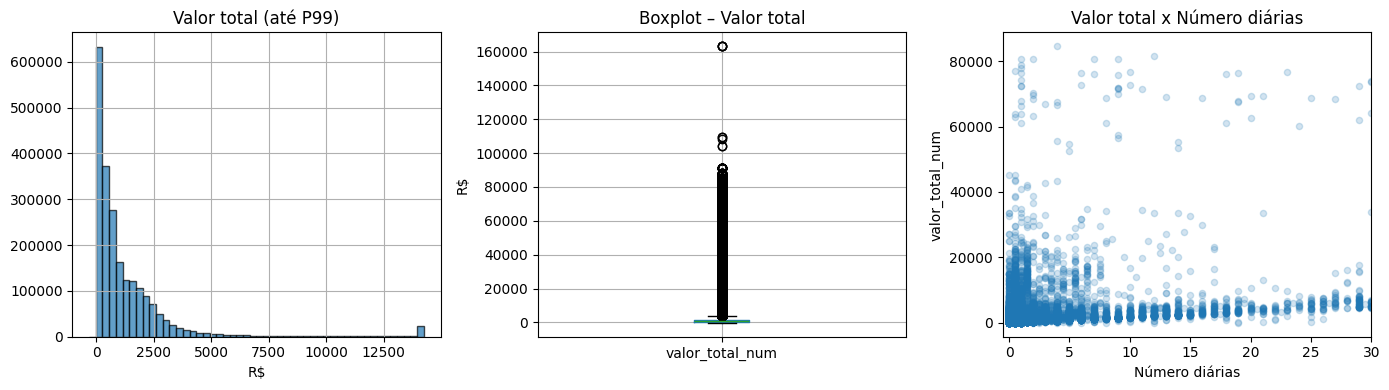

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4)) # instancia o grafico com 1 linha e 3 colunas   

y = df['valor_total_num'].dropna() # Cria um DataFrame y contendo os valores não nulos da coluna 'valor_total_num' do DataFrame df.
y99 = y.clip(upper=y.quantile(0.99)) # Calcula o percentil 99 dos valores de y e limita os valores acima desse percentil a esse valor.
y99.hist(ax=axes[0], bins=50, edgecolor='black', alpha=0.7) # Plota o histograma dos valores de y99.
axes[0].set_title('Valor total (até P99)') # Define o título do histograma.
axes[0].set_xlabel('R$') # Define o rótulo do eixo x do histograma.

df.boxplot(column='valor_total_num', ax=axes[1]) # Plota o boxplot dos valores de 'valor_total_num' do DataFrame df.
axes[1].set_title('Boxplot – Valor total') # Define o título do boxplot.
axes[1].set_ylabel('R$') # Define o rótulo do eixo y do boxplot.

col_nd = col_num_diarias if col_num_diarias in df.columns else COLS_NUM[-1] if COLS_NUM else 'valor_total_num' # Define a coluna col_nd como a coluna 'Número diárias' se ela estiver presente no DataFrame df.columns, caso contrário, define col_nd como o último elemento da lista COLS_NUM ou 'valor_total_num'.
amostra = df[[col_nd, 'valor_total_num']].dropna().sample(n=min(50000, len(df)), random_state=42) # Cria um DataFrame amostra contendo as colunas col_nd e 'valor_total_num' do DataFrame df, removendo valores nulos e amostrando aleatoriamente n=min(50000, len(df)) valores.    
amostra.plot.scatter(x=col_nd, y='valor_total_num', alpha=0.2, ax=axes[2]) # Plota o gráfico de dispersão dos valores de col_nd e 'valor_total_num' do DataFrame amostra.
axes[2].set_xlim(-0.5, 30) # Define o limite do eixo x do gráfico de dispersão. 
axes[2].set_title('Valor total x Número diárias') # Define o título do gráfico de dispersão.
plt.tight_layout() # Ajusta o layout dos subplots para que eles não se sobreponham.
plt.show() # Exibe o gráfico.

**Leitura dos gráficos**

- **Histograma (Valor total até P99):** No eixo horizontal estão faixas de valor em R$; no vertical, a quantidade de registros em cada faixa. A forma da distribuição mostra onde a maioria dos gastos se concentra (ex.: pico em valores baixos) e se há **assimetria** (cauda longa para a direita indica muitos valores altos). Valores acima do P99 foram cortados para não comprimir a visualização da parte central.  
  **O que está significando:** A maior parte das despesas tende a ficar em faixas mais baixas (viagens curtas ou só diárias), enquanto uma minoria de registros puxa a média para cima (viagens longas ou com passagens caras). Isso indica que o **target (Valor total) não é simétrico** e que na regressão pode ser útil usar **transformação** (ex.: log) ou tratar outliers para o modelo não ser dominado por poucos valores muito altos.

- **Boxplot (Valor total):** A caixa representa o intervalo entre Q1 e Q3 (25% e 75%); a linha dentro da caixa é a **mediana**. Os “bigodes” vão até 1,5× a amplitude interquartílica; pontos além deles são **outliers**.  
  **O que está significando:** A mediana indica o valor "típico" de uma despesa; a caixa mostra onde está concentrada a metade central dos dados. Muitos **pontos acima do bigode** significam que há **gastos atípicos** (possíveis viagens de alto custo ou erros de lançamento). Para a modelagem, isso reforça a necessidade de decidir se esses valores serão mantidos, limitados (cap) ou se o modelo será ajustado em log(Valor total) para reduzir o peso dos extremos.

- **Dispersão (Número diárias × Valor total):** Cada ponto é um registro (amostra). No eixo X está o número de diárias; no Y, o valor total em R$. Uma **nuvem com tendência ascendente** indica que, em média, mais diárias estão associadas a maior gasto; a espessura da nuvem mostra a **variabilidade**.  
  **O que está significando:** A tendência positiva indica que **Número diárias** é uma preditora relevante para o Valor total (mais dias de viagem, em geral, mais custo). A **dispersão em torno da tendência** significa que o valor não depende só do número de diárias: **motivo da viagem, meio de transporte, órgão e destino** também influenciam. Na prática, o modelo de regressão deve incluir essas outras variáveis para prever melhor; usar só Número diárias tende a deixar grande parte da variação sem explicação.

## 4. Discussão Preliminar

Com base nas seções 3.1 (incluindo **3.1.1** valores ausentes, **3.1.2** correlação e **3.1.3** one-hot encoding) e **3.2**, destaque:

**Padrões e relações:** A variável **Valor total** costuma apresentar **forte assimetria positiva** (média bem acima da mediana) e alto **CV%**, com outliers visíveis no boxplot. O gráfico **Número diárias × Valor total** tende a mostrar **relação positiva**, mas com muita variabilidade, sugerindo que Motivo, Meio de transporte e órgão serão importantes. **Valor passagem** é zero em muitos registros (apenas diária); quando há passagem, os valores podem ser elevados.

**Qualidade dos dados:** Cargo tem elevada proporção de nulos; **Município/UF** e **Categoria passagem** têm muitos nulos quando não há trecho de passagem. Colunas monetárias e Número diárias exigem conversão de vírgula para ponto (feita na carga); datas devem ser convertidas para datetime para derivar duração e mês/ano. Duplicatas foram removidas.

**Implicações para a modelagem:** Considerar transformação no target (ex.: log(1+y)); encoding para Motivo e Meio de transporte; agrupamento de categorias raras; decisão sobre subconjunto (todos vs. só com passagem) e validação temporal (treino/teste por período).

---

## 5. Próximos Passos

**Ajustes nos dados:** Garantir datas em datetime e criar duração da viagem, mês e ano; tratar nulos em Cargo, Município/UF e Categoria passagem; agrupar categorias raras em Motivo e Meio de transporte; avaliar transformação no target (log) ou tratamento de outliers.

**Variáveis:** Alvo = **Valor total** (regressão). Preditoras candidatas: Número diárias, duração, mês, ano, Motivo, Meio de transporte, órgão (codificado/agrupado). Evitar Nome servidor (muitas categorias).

**Encoding:** Na regressão linear, usar **one-hot com `drop_first`** nas categóricas de **baixa cardinalidade** (ver **3.1.3**); para nomes de órgão, UG, município ou servidor, **não** usar one-hot direto — preferir agregação, nível hierárquico (ex.: só órgão superior) ou algoritmos que suportem muitas categorias com regularização.

**Modelagem:** Split treino/validação/teste (considerar hold-out temporal). Modelos: regressão linear (baseline), árvore, random forest, gradient boosting. Métricas: RMSE, MAE, R² (e eventualmente MAPE). Pipeline com encoding e escalonamento conforme o algoritmo.

---

## Referências

- **Viagens a serviço do governo federal (SCDP)** — Dados abertos: [dados.gov.br – conjunto SCDP](https://dados.gov.br/dados/conjuntos-dados/viagens-a-servico-do-governo-federal-scdp).
- **Sistema SCDP:** [novoscdp – home](https://www2.scdp.gov.br/novoscdp/home.xhtml).
- **Portal da Transparência — Viagens a Serviço:** [visão geral](https://portaldatransparencia.gov.br/viagens/visao-geral).
- Documento do projeto: `pre_projeto_diarias_passagens.md`.